In [ ]:
import graphviz
import numpy as np

In [ ]:
class Value:
    def __init__(self, value, children=None, label=None):
        self.value = value
        self.children = children if isinstance(children, list) else []
        self.label = label
        self.grad = 0
        self.backprop = None
        self.op = None

    def __add__(self, other):
        # self + other
        if not isinstance(other, Value):
            other = Value(other)
        out = Value(self.value + other.value, [self, other])
        out.op = '+'

        def backprop():
            self.grad += out.grad
            other.grad += out.grad

        out.backprop = backprop

        return out

    def __radd__(self, other):
        # other + self
        return self.__add__(other)

    def __sub__(self, other):
        # self - other
        return self.__add__(-other)

    def __rsub__(self, other):
        # other - self
        return (-self).__add__(other)

    def __neg__(self):
        # -self
        out = Value(-self.value, [self], label=f'-{self.label}')
        out.op = '-'

        def backprop():
            self.grad += -out.grad

        out.backprop = backprop

        return out

    def __mul__(self, other):
        # self * other
        if not isinstance(other, Value):
            other = Value(other)
        out = Value(self.value * other.value, [self, other])
        out.op = '*'

        def backprop():
            self.grad += other.value*out.grad
            other.grad += self.value*out.grad

        out.backprop = backprop

        return out

    def __rmul__(self, other):
        # other * self
        return self.__mul__(other)

    def __pow__(self, other):
        # self ** other
        assert isinstance(other, int) or isinstance(other, float)
        out = Value(self.value ** other, [self])
        out.op = '**'

        def backprop():
            self.grad += (other)*(out.grad)*(self.value**(other-1))

        out.backprop = backprop

        return out

        # g = a**10
        # g.backprop()

    def __truediv__(self, other):
        # self / other
        return self * (other ** -1)

    def __rtruediv__(self, other):
        # other / self
        return other * (self ** -1)

    def tanh(self):
        out = Value(np.tanh(self.value), children=[self])
        out.op = "tanh"
        def backprop():
            self.grad += (1 - out.value ** 2) * out.grad

        out.backprop = backprop

        return out

    def __repr__(self) -> str:
        return f'{self.label} | {self.value} | {self.op}'

In [ ]:
def build_graph(root):
    g = graphviz.Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes = [root]
    if root.label:
      label_str = f'{{ {root.label} | data {root.value:.4f} | grad {root.grad:.4f} }}'
    else:
      label_str = f'{{ {root.value:.4f} | grad {root.grad:.4f} }}'
    g.node(str(id(root)), label_str, shape='record')
    while len(nodes):
      cur = nodes[-1]
      nodes.pop()
      if len(cur.children):
        op_node_id = str(id(cur)) + cur.op
        g.node(op_node_id, str(cur.op))
        g.edge(op_node_id, str(id(cur)))
        for child in cur.children:
          if child.label:
            label_str = f'{{ {child.label} | data {child.value:.4f} | grad {child.grad:.4f} }}'
          else:
            label_str = f'{{ {child.value:.4f} | grad {child.grad:.4f} }}'
          g.node(str(id(child)), label_str, shape='record')
          g.edge(str(id(child)), op_node_id)
          nodes.append(child)

    return g

In [ ]:
a = Value(2, label='a')
b = Value(3, label='b')
d = Value(4, label='d')

def forward():
  c = a - b; c.label = 'c'
  e = d - c; e.label = 'e'
  f = e * 3; f.label = 'f'
  L = f / a; L.label = 'L'
  return L

In [ ]:
def topo(root)->list[Value]:
  in_deg = {}
  nodes = [root]
  for n in nodes:
    for c in n.children:
      in_deg[c] = in_deg.get(c, 0) + 1
      if in_deg[c] == 1:
        nodes.append(c)

  res = [root]
  for n in res:
    for c in n.children:
      in_deg[c] -= 1
      if in_deg[c] == 0:
        res.append(c)
  return res

In [ ]:
def backprop(root):
  root.grad = 1.0;
  nodes = topo(root)
  for node in nodes:
    if node.backprop:
      node.backprop()

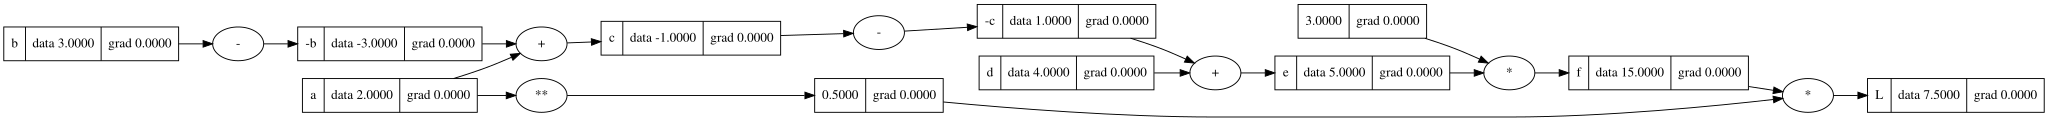

In [ ]:
# for n in range(1):
l = forward()
dot = build_graph(l)
dot

In [ ]:
def train(num_steps):
  for _ in range(num_steps):
    L = forward()
    backprop(L)
    nodes = [L]
    for node in nodes:
      if not node.children:
        node.value -= 0.01*node.grad
      else:
        for child in node.children:
          nodes.append(child)
      node.grad = 0

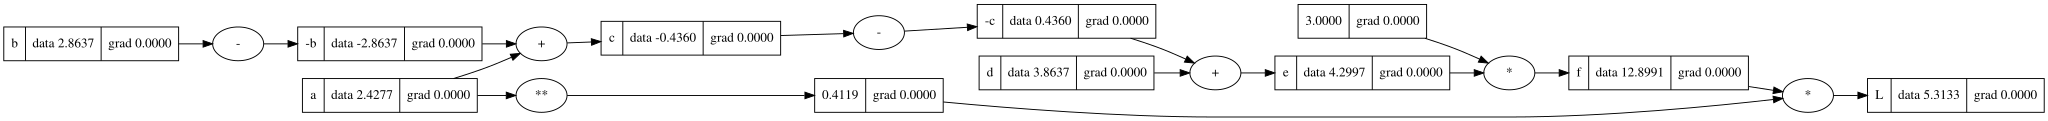

In [ ]:
train(10)
l = forward()
dot = build_graph(l)
dot

In [ ]:
import random
import math
random.seed(42)

In [ ]:
class Neuron:
  def __init__(self, input_dim, layer_id, neuron_id):
    self.input_dim = input_dim
    self.layer_id = layer_id
    self.neuron_id = neuron_id
    scale = 1.0 / math.sqrt(input_dim)
    self.weights = [Value(random.uniform(-scale, scale), label=f'weight:{layer_id}:{neuron_id}:{i}') for i in range(input_dim)]
    self.bias = Value(0, label=f'bias:{layer_id}:{neuron_id}')

  def __call__(self, x):
    return self.fwd(x)

  def fwd(self, x: list):
    assert len(x) == self.input_dim
    res = self.bias
    for xi, wi in zip(x, self.weights):
      res += xi*wi
    return res.tanh()

  @property
  def parameters(self):
    return self.weights + [self.bias]


In [ ]:
class Layer:
  def __init__(self, input_dim, output_dim, layer_id):
    self.input_dim = input_dim
    self.output_dim = output_dim
    self.layer_id = layer_id
    self.neurons = [Neuron(input_dim, layer_id, i) for i in range(output_dim)]

  def __call__(self, x):
    return self.fwd(x)

  def fwd(self, x: list):
    assert len(x) == self.input_dim
    res = []
    for ni in self.neurons:
      res.append(ni(x))
    return res

  @property
  def parameters(self):
    return [p for n in self.neurons for p in n.parameters]


In [ ]:
class MLP:
  def __init__(self, input_dim: int, layer_dims: list):
    self.input_dim = input_dim
    self.layer_dims = layer_dims
    self.layers = []
    prev_dim = input_dim
    for i, layer_dim in enumerate(layer_dims):
      self.layers.append(Layer(prev_dim, layer_dim, layer_id=i))
      prev_dim = layer_dim

  def __call__(self, input):
    return self.fwd(input)

  def fwd(self, x):
    assert len(x) == self.input_dim
    for layer in self.layers:
      x = layer(x)
    return x

  @property
  def parameters(self):
    return [p for l in self.layers for p in l.parameters]

In [ ]:
# a*a + b*b <= 0.5
max_n = 1
data_size = 500
input_data = [(random.uniform(-max_n, max_n), random.uniform(-max_n, max_n)) for _ in range(data_size)]
expected_data = [1 if d[0]*d[0] + d[1]*d[1] <= 0.5 else -1 for d in input_data]

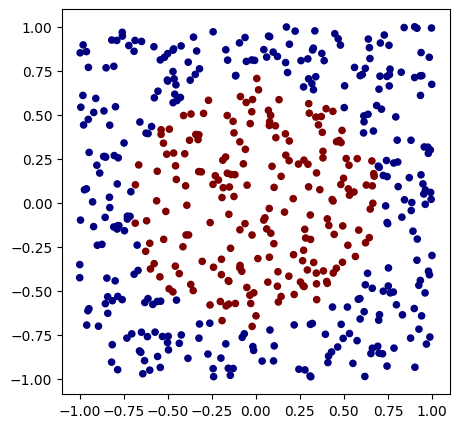

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert input_data to a NumPy array for correct indexing
input_data_np = np.array(input_data)

# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(input_data_np[:,0], input_data_np[:,1], c=expected_data, s=20, cmap='jet')

In [ ]:
nn = MLP(input_dim=2, layer_dims=[8, 16, 16, 8, 1])

In [ ]:
# def L2Loss(out, label):
#   out = (out - label)**2
#   return out

def HingeSquareLoss(out, label):
  # For binary classification with labels -1 and 1, and tanh output in (-1, 1)
  # This loss penalizes misclassifications (label*out < 0)
  # and encourages correct classifications (label*out near 1)
  return (Value(1) - label * out) ** 2

def train():
  lr = 0.05
  n_epochs = 60
  batch_size = 10

  for e in range(n_epochs):
    # Shuffle data each epoch
    combined = list(zip(input_data, expected_data))
    random.shuffle(combined)
    shuffled_inputs, shuffled_labels = zip(*combined)

    for b in range(data_size // batch_size):
      loss = Value(0)
      for inp, label in zip(shuffled_inputs[b*batch_size:(b+1)*batch_size], shuffled_labels[b*batch_size:(b+1)*batch_size]):
        # Forward
        out = nn(inp)[0]
        # Loss
        loss += HingeSquareLoss(out, label)

      loss /= batch_size
      loss.label = "Loss"
      print(loss)

      # Backward
      backprop(loss)

      # Weight Updates
      for node in nn.parameters:
        clipped_grad = min(10, max(-10, node.grad))
        node.value -= lr * clipped_grad
        node.grad = 0

In [ ]:
train()

Loss | 1.0225514947386258 | *
Loss | 1.0217315989451443 | *
Loss | 0.9466529976521874 | *
Loss | 0.9720686726178122 | *
Loss | 1.048537160356856 | *
Loss | 1.0219227408776814 | *
Loss | 1.0022917117537404 | *
Loss | 1.006457171342967 | *
Loss | 1.0619831648366653 | *
Loss | 0.9995940632027566 | *
Loss | 0.9444968070006032 | *
Loss | 1.0257232180751854 | *
Loss | 1.0065875198658512 | *
Loss | 1.057868300499926 | *
Loss | 0.9745142147388481 | *
Loss | 1.023506441083403 | *
Loss | 0.9925306171867754 | *
Loss | 1.0318697949455897 | *
Loss | 1.007654467848112 | *
Loss | 0.9919904967707578 | *
Loss | 1.045015080441092 | *
Loss | 0.9455021816048719 | *
Loss | 1.0922976792464618 | *
Loss | 0.9979556371125015 | *
Loss | 0.984615023099585 | *
Loss | 0.9785632533390238 | *
Loss | 1.0112661033674688 | *
Loss | 0.9366862263084225 | *
Loss | 0.8849185949165274 | *
Loss | 1.0962682361442222 | *
Loss | 0.9313688059552668 | *
Loss | 0.8093059381270304 | *
Loss | 0.9361415436060521 | *
Loss | 0.92988569

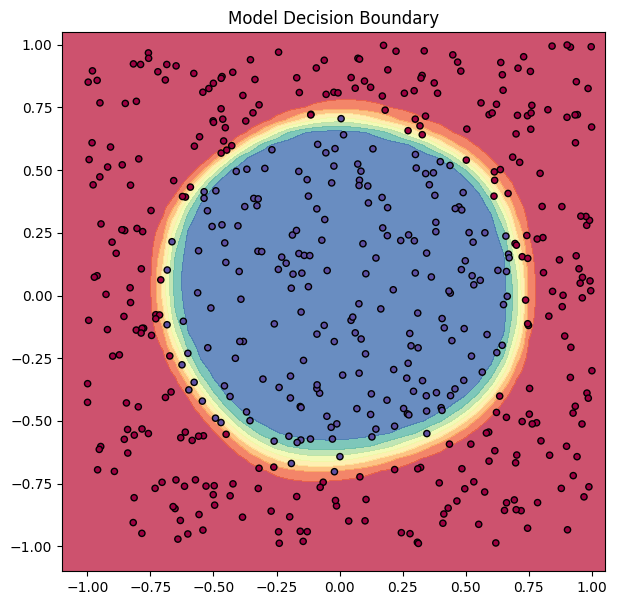

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_boundary(model, input_data_np, expected_data):
    # 1. Create a grid of points
    h = 0.05 # step size in the mesh
    x_min, x_max = -1.1, 1.1
    y_min, y_max = -1.1, 1.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # 2. Evaluate the model on every point in the grid
    X_grid = np.c_[xx.ravel(), yy.ravel()]
    inputs = [list(map(float, x)) for x in X_grid]

    scores = []
    for x in inputs:
        # Pass through MLP and get the scalar output value
        out = model(x)[0]
        scores.append(out.value)

    Z = np.array(scores).reshape(xx.shape)

    # 3. Plot the result
    plt.figure(figsize=(7, 7))

    # Draw the decision regions (where score > 0 is one class, < 0 is another)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)

    # Overlay the original training data
    plt.scatter(input_data_np[:, 0], input_data_np[:, 1], c=expected_data, s=20, edgecolors='k', cmap=plt.cm.Spectral)

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("Model Decision Boundary")
    plt.show()

visualize_boundary(nn, input_data_np, expected_data)

In [ ]:
import torch

# TEST 1
x = Value(-4.0)
z = 2 * x + 2 + x
q = z.tanh() + z * x
h = (z * z).tanh()
y = h + q + q * x
backprop(y)
xmg, ymg = x, y
xmg.grad, ymg.value

(np.float64(104.99999992992078), np.float64(-116.00000001236691))

In [ ]:
x = torch.Tensor([-4.0]).double()
x.requires_grad = True
z = 2 * x + 2 + x
q = z.tanh() + z * x
h = (z * z).tanh()
y = h + q + q * x
y.backward()
xpt, ypt = x, y

xpt.grad.item(), ypt.data.item()

(104.99999992992078, -116.00000001236691)

In [ ]:
# TEST 2
a = Value(-4.0)
b = Value(2.0)
c = a + b
d = a * b + b**3
c += c + 1
c += 1 + c + (-a)
d += d * 2 + (b + a).tanh()
d += 3 * d + (b - a).tanh()
e = c - d
f = e**2
g = f / 2.0
g += 10.0 / f
backprop(g)
amg, bmg, gmg = a, b, g

a = torch.Tensor([-4.0]).double()
b = torch.Tensor([2.0]).double()
a.requires_grad = True
b.requires_grad = True
c = a + b
d = a * b + b**3
c = c + c + 1
c = c + 1 + c + (-a)
d = d + d * 2 + (b + a).tanh()
d = d + 3 * d + (b - a).tanh()
e = c - d
f = e**2
g = f / 2.0
g = g + 10.0 / f
g.backward()
apt, bpt, gpt = a, b, g

tol = 1e-6
# forward pass went well
assert abs(gmg.value - gpt.data.item()) < tol
# backward pass went well
assert abs(amg.grad - apt.grad.item()) < tol
assert abs(bmg.grad - bpt.grad.item()) < tol